In [1]:
# =============================================================================
# CELL 1 — IMPORTS
# =============================================================================
import sys
sys.path.append('..')

from shared.supabase_client import fetch_all, get_client
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

print('✅ Imports ready')

✅ Imports ready


In [2]:
# =============================================================================
# CELL 2 — LOAD DATA
# =============================================================================
print(' Loading data...')
sessions = fetch_all('live_sessions')
brands = fetch_all('brands')

brand_map = dict(zip(brands['brand_id'], brands['brand_name']))
sessions['brand_name'] = sessions['brand_id'].map(brand_map)
sessions['total_revenue'] = sessions['revenue_shopee'].fillna(0) + sessions['revenue_tiktok'].fillna(0)
sessions['total_viewers'] = sessions['viewers_shopee'].fillna(0) + sessions['viewers_tiktok'].fillna(0)
sessions['total_likes'] = sessions['likes_shopee'].fillna(0) + sessions['likes_tiktok'].fillna(0)

df = sessions.groupby(['brand_id', 'brand_name', 'period_id']).agg(
    total_revenue=('total_revenue', 'sum'),
    total_sessions=('id', 'count'),
    avg_viewers=('total_viewers', 'mean'),
    total_likes=('total_likes', 'sum'),
    unique_hosts=('host_id', 'nunique'),
).reset_index()

df = df[df['total_revenue'] > 0].copy()
print(f'✅ {len(df)} rows, {df["brand_name"].nunique()} brands')

 Loading data...
✅ 79 rows, 5 brands


In [4]:
def prepare_brand_data(df, brand_name):
    """Create ML features for one brand"""
    bdf = df[df['brand_name'] == brand_name].sort_values('period_id').copy()
    
    # --- LAG FEATURES (Previous period values) ---
    bdf['revenue_lag1'] = bdf['total_revenue'].shift(1)      # 1 period ago
    bdf['revenue_lag2'] = bdf['total_revenue'].shift(2)      # 2 periods ago
    bdf['sessions_lag1'] = bdf['total_sessions'].shift(1)    # Sessions 1 period ago
    bdf['viewers_lag1'] = bdf['avg_viewers'].shift(1)        # Viewers 1 period ago
    
    # --- ROLLING AVERAGES (Momentum) ---
    # CRITICAL: shift(1) BEFORE rolling — prevents data leakage!
    bdf['revenue_rolling3'] = bdf['total_revenue'].shift(1).rolling(3, min_periods=1).mean()
    
    # --- GROWTH RATE ---
    bdf['revenue_growth'] = (bdf['revenue_lag1'] / bdf['revenue_lag2'].replace(0, np.nan)) - 1
    
    # --- EFFICIENCY ---
    bdf['rev_per_session'] = bdf['revenue_lag1'] / bdf['sessions_lag1'].replace(0, np.nan)
    
    return bdf.replace([np.inf, -np.inf], np.nan).dropna()


# Combine all 5 brands into ONE dataset
all_data = []
le = LabelEncoder()  # Converts brand names → numbers

for brand in df['brand_name'].unique():
    bdf = prepare_brand_data(df, brand)
    if len(bdf) > 3:
        bdf['brand_name_col'] = brand
        all_data.append(bdf)

combined = pd.concat(all_data, ignore_index=True)
combined['brand_code'] = le.fit_transform(combined['brand_name_col'])
# SPECS=0, PIERO=1, MINERAL=2, FISIK SPORT=3, C&F=4

In [12]:
# =============================================================================
# CELL 4 — TRAIN LSTM MODEL
# =============================================================================

print('🔄 Training LSTM...')

# Scale data to 0-1 range
sX, sy = MinMaxScaler(), MinMaxScaler()
Xs = sX.fit_transform(X_all)
ys = sy.fit_transform(y_all.reshape(-1, 1))

# Reshape for LSTM [samples, timesteps, features]
Xl = Xs.reshape(Xs.shape[0], 1, Xs.shape[1])

# Build LSTM architecture
model = Sequential([
    LSTM(64, activation='relu', input_shape=(1, len(FEATURES)), return_sequences=True),
    Dropout(0.3),
    LSTM(32, activation='relu'),
    Dropout(0.3),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(Xl, ys, epochs=80, batch_size=8, validation_split=0.2, verbose=0)

# Evaluate
yp = np.maximum(sy.inverse_transform(model.predict(Xl, verbose=0)).flatten(), 0)
r2 = r2_score(y_all, yp)
mae = mean_absolute_error(y_all, yp)

print(f'✅ LSTM Trained — R²: {r2:.3f} | MAE: Rp {mae:,.0f}')

🔄 Training LSTM...
✅ LSTM Trained — R²: 0.556 | MAE: Rp 108,937,831


In [13]:
# =============================================================================
# CELL 5 — FORECAST NEXT PERIOD
# =============================================================================

print('=' * 60)
print('📊 REVENUE FORECAST — LSTM MODEL')
print('=' * 60)

forecasts = {}

for brand in df['brand_name'].unique():
    bdf = prepare_brand_data(df, brand)
    if bdf is None or len(bdf) < 3:
        continue
    
    # Get last row + brand code
    last = bdf.iloc[-1:].copy()
    last['brand_code'] = le.transform([brand])[0]
    
    # Prepare features
    X_last = last[FEATURES].values
    X_last_s = sX.transform(X_last).reshape(1, 1, -1)
    
    # Predict
    pred = max(0, sy.inverse_transform(model.predict(X_last_s, verbose=0))[0][0])
    
    actual = bdf['total_revenue'].iloc[-1]
    pct = ((pred - actual) / actual * 100) if actual > 0 else 0
    
    icon = '📈' if pct > 0 else '📉'
    warn = ' ⚠️' if abs(pct) > 50 else ''
    
    print(f'\n{icon} {brand}{warn} ({len(bdf)} periods)')
    print(f'   Last Period : Rp {actual:,.0f}')
    print(f'   Next Period : Rp {pred:,.0f}')
    print(f'   Change      : {pct:+.1f}%')
    
    forecasts[brand] = {
        'prediction': pred,
        'actual_last': actual,
        'pct_change': pct,
        'periods': len(bdf),
    }

print(f'\n{"="*60}')
print(f'✅ Model R²: {r2:.3f} | MAE: Rp {mae:,.0f}')

📊 REVENUE FORECAST — LSTM MODEL

📉 SPECS (18 periods)
   Last Period : Rp 762,898,797
   Next Period : Rp 418,959,680
   Change      : -45.1%

📈 PIERO (23 periods)
   Last Period : Rp 65,639,355
   Next Period : Rp 80,167,912
   Change      : +22.1%

📈 MINERAL BOTANICAL (7 periods)
   Last Period : Rp 241,930,755
   Next Period : Rp 250,481,536
   Change      : +3.5%

📈 FISIK SPORT ⚠️ (12 periods)
   Last Period : Rp 36,005,167
   Next Period : Rp 113,908,392
   Change      : +216.4%

📉 C&F (9 periods)
   Last Period : Rp 291,960,867
   Next Period : Rp 243,354,672
   Change      : -16.6%

✅ Model R²: 0.556 | MAE: Rp 108,937,831


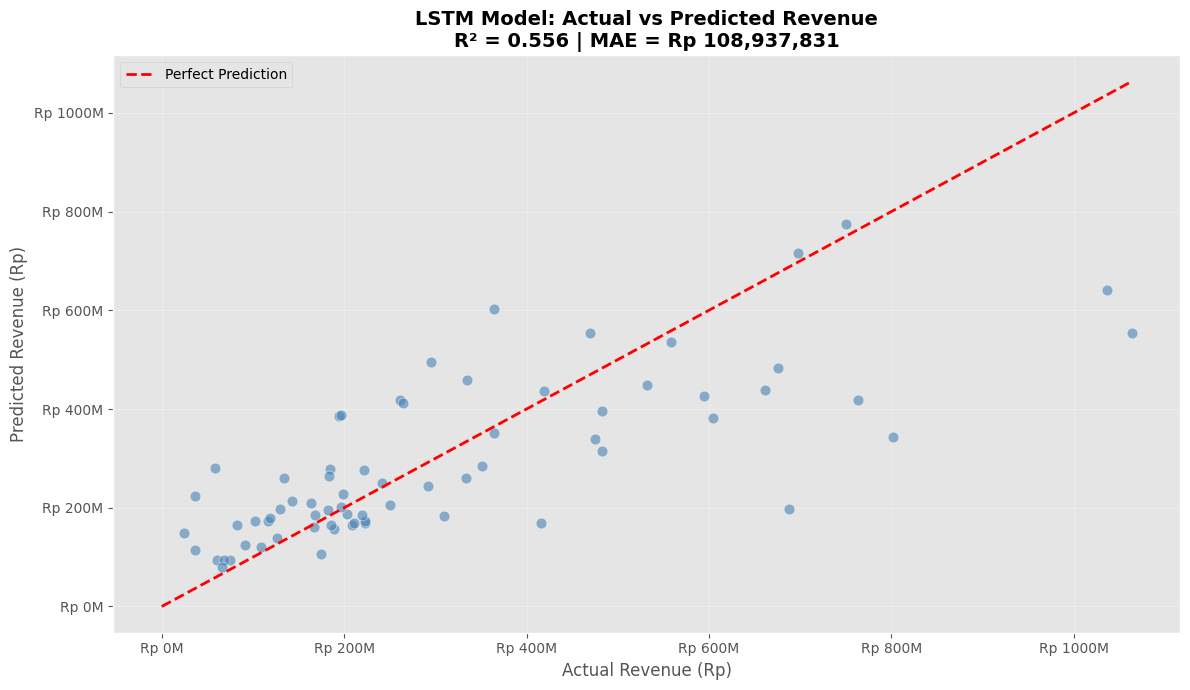

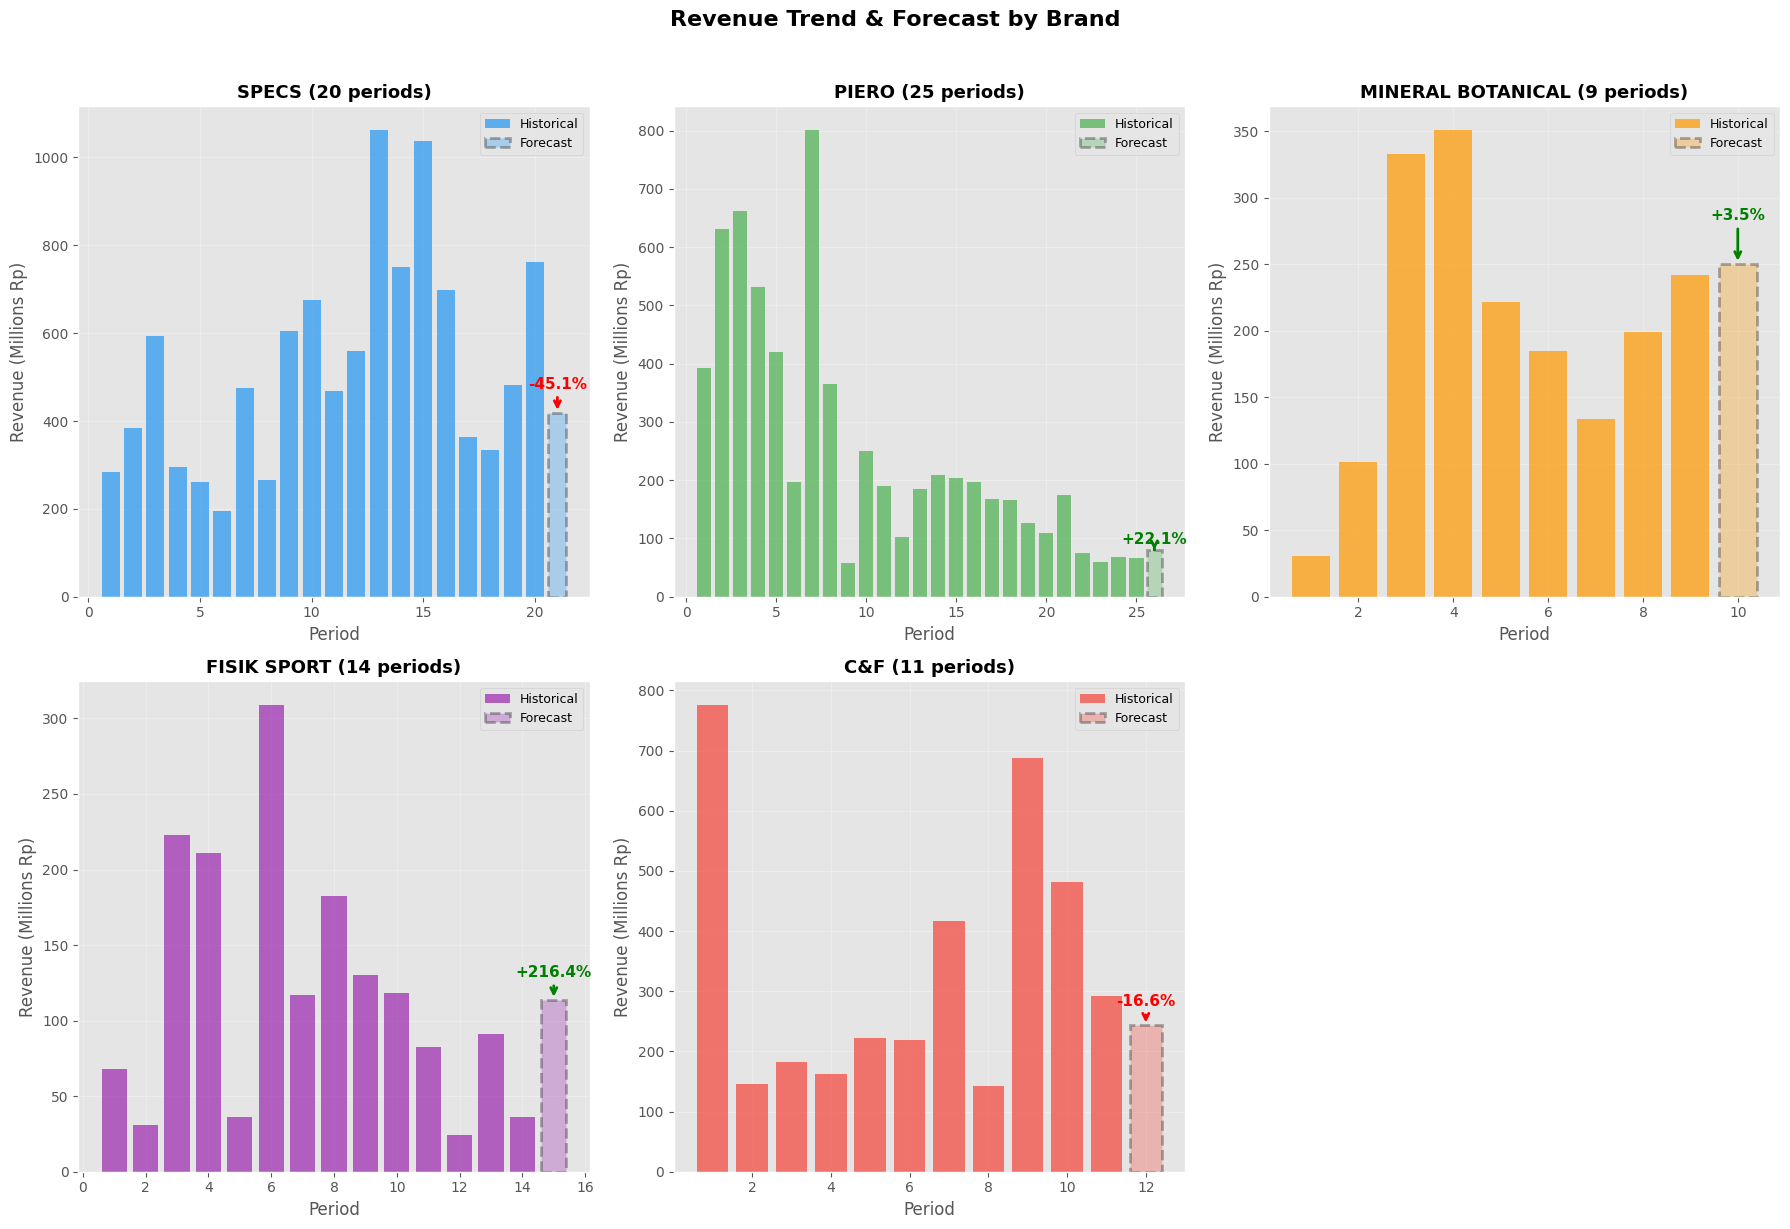

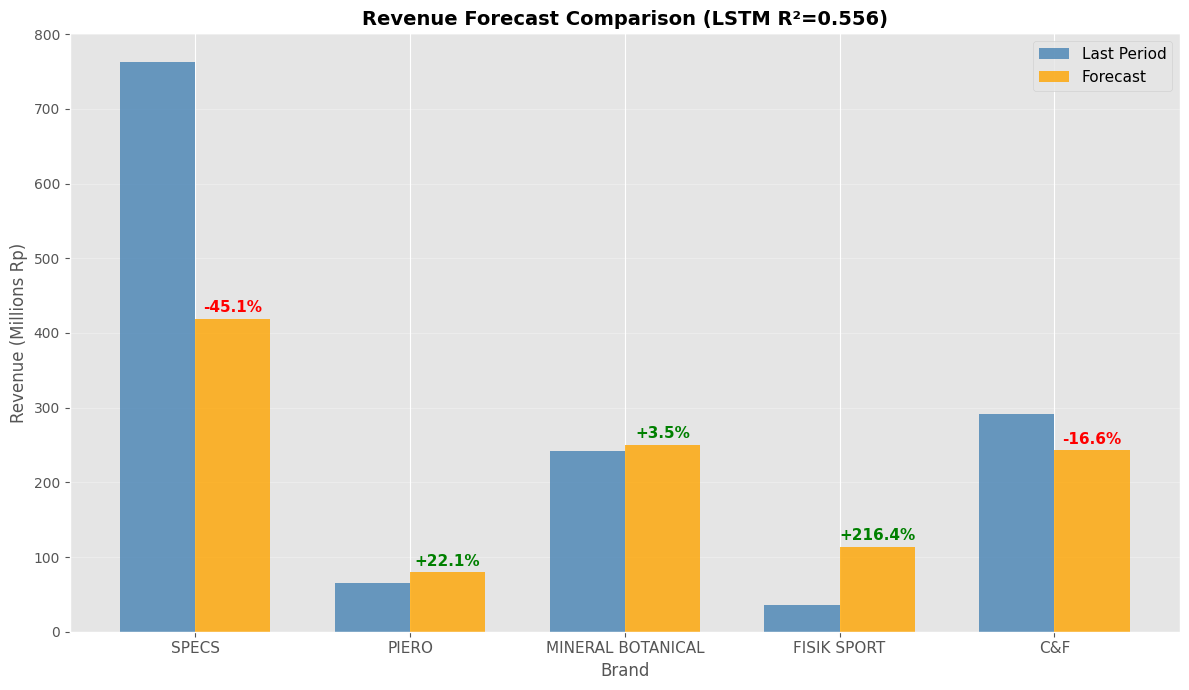


✅ All 3 visualizations complete!
   Saved: actual_vs_predicted.png
   Saved: brand_forecasts.png
   Saved: forecast_comparison.png


In [14]:
# =============================================================================
# CELL 5B — VISUALIZATIONS
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.style.use('ggplot')

# ============================================================
# CHART 1: Actual vs Predicted (All Data)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(y_all, yp, alpha=0.6, s=60, c='steelblue', edgecolors='white', linewidth=0.5)

max_val = max(y_all.max(), yp.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax.set_xlabel('Actual Revenue (Rp)', fontsize=12)
ax.set_ylabel('Predicted Revenue (Rp)', fontsize=12)
ax.set_title(f'LSTM Model: Actual vs Predicted Revenue\nR² = {r2:.3f} | MAE = Rp {mae:,.0f}', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'Rp {x/1e6:.0f}M'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'Rp {x/1e6:.0f}M'))

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# CHART 2: Revenue Trend Per Brand
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

for idx, brand in enumerate(df['brand_name'].unique()):
    ax = axes[idx]
    bdf = df[df['brand_name'] == brand].sort_values('period_id')
    periods = bdf['period_id'].values
    revenues = bdf['total_revenue'].values
    
    ax.bar(periods, revenues / 1e6, color=colors[idx], alpha=0.7, label='Historical')
    
    if brand in forecasts:
        next_p = periods[-1] + 1
        next_r = forecasts[brand]['prediction']
        ax.bar(next_p, next_r / 1e6, color=colors[idx], alpha=0.3,
               edgecolor='black', linewidth=2, linestyle='--', label='Forecast')
        
        pct = forecasts[brand]['pct_change']
        color = 'green' if pct > 0 else 'red'
        ax.annotate(f'{pct:+.1f}%',
                   xy=(next_p, next_r / 1e6),
                   xytext=(next_p, next_r / 1e6 * 1.13),
                   fontsize=11, fontweight='bold', color=color, ha='center',
                   arrowprops=dict(arrowstyle='->', color=color, lw=2))
    
    ax.set_title(f'{brand} ({len(bdf)} periods)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Period')
    ax.set_ylabel('Revenue (Millions Rp)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[5].set_visible(False)
plt.suptitle('Revenue Trend & Forecast by Brand', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('brand_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# CHART 3: Forecast Comparison
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))

brands = list(forecasts.keys())
last_vals = [forecasts[b]['actual_last'] / 1e6 for b in brands]
pred_vals = [forecasts[b]['prediction'] / 1e6 for b in brands]
pct_changes = [forecasts[b]['pct_change'] for b in brands]

x = np.arange(len(brands))
width = 0.35

ax.bar(x - width/2, last_vals, width, label='Last Period', color='steelblue', alpha=0.8)
bars = ax.bar(x + width/2, pred_vals, width, label='Forecast', color='orange', alpha=0.8)

for i, (bar, pct) in enumerate(zip(bars, pct_changes)):
    color = 'green' if pct > 0 else 'red'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(pred_vals)*0.02,
            f'{pct:+.1f}%', ha='center', fontsize=11, fontweight='bold', color=color)

ax.set_xlabel('Brand', fontsize=12)
ax.set_ylabel('Revenue (Millions Rp)', fontsize=12)
ax.set_title(f'Revenue Forecast Comparison (LSTM R²={r2:.3f})', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(brands, fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ All 3 visualizations complete!')
print('   Saved: actual_vs_predicted.png')
print('   Saved: brand_forecasts.png')
print('   Saved: forecast_comparison.png')

In [ ]:
# Quick check
print(df.columns)
# Drop the target if it's in X
X = df.drop('Actual_Revenue', axis=1, errors='ignore')
y = df['Actual_Revenue']


In [ ]:
# # =============================================================================
# # CELL 6 — SAVE TO DATABASE
# # =============================================================================

# from datetime import datetime

# supabase = get_client()

# # Clear old predictions
# print('🗑️  Clearing old predictions...')
# supabase.table('revenue_predictions').delete().neq('id', 0).execute()

# saved = 0
# for brand, fc in forecasts.items():
#     next_period = df[df['brand_name'] == brand]['period_id'].max() + 1
    
#     supabase.table('revenue_predictions').insert({
#         'period_id': int(next_period),
#         'period_name': f'{brand} Period {int(next_period)}',
#         'date': datetime.now().date().isoformat(),
#         'actual': None,
#         'predicted': int(fc['prediction']),
#         'is_future': True,
#         'model_r2': float(r2),
#         'model_mae': float(mae),
#         'model_slope': 0,
#     }).execute()
#     saved += 1

# print(f'✅ {saved} predictions saved to Supabase!')

In [15]:
# =============================================================================
# CELL 7 — DASHBOARD SUMMARY
# =============================================================================

print('=' * 65)
print('📊 VIDHELP ADMIN DASHBOARD — REVENUE FORECAST')
print('=' * 65)
print(f'Model: LSTM Neural Network | R²: {r2:.3f} | Data: {len(X_all)} brand-periods')
print('=' * 65)

for brand, fc in forecasts.items():
    icon = '📈' if fc['pct_change'] > 0 else '📉'
    warn = ' ⚠️ VERIFY' if abs(fc['pct_change']) > 50 else ''
    print(f'{icon} {brand:<20} Rp {fc["actual_last"]:>12,.0f} → Rp {fc["prediction"]:>12,.0f} ({fc["pct_change"]:>+.1f}%){warn}')

print('=' * 65)
print('⚠️  Brands with >50% change flagged for business review')
print('=' * 65)
print('✅ Pipeline complete — Predictions saved to revenue_predictions table')

📊 VIDHELP ADMIN DASHBOARD — REVENUE FORECAST
Model: LSTM Neural Network | R²: 0.556 | Data: 69 brand-periods
📉 SPECS                Rp  762,898,797 → Rp  418,959,680 (-45.1%)
📈 PIERO                Rp   65,639,355 → Rp   80,167,912 (+22.1%)
📈 MINERAL BOTANICAL    Rp  241,930,755 → Rp  250,481,536 (+3.5%)
📈 FISIK SPORT          Rp   36,005,167 → Rp  113,908,392 (+216.4%) ⚠️ VERIFY
📉 C&F                  Rp  291,960,867 → Rp  243,354,672 (-16.6%)
⚠️  Brands with >50% change flagged for business review
✅ Pipeline complete — Predictions saved to revenue_predictions table
